### Visualization

In [1]:
from helper_functions import *
import os
from datetime import datetime
print(os.getcwd())
params = 'window_t_L_12.56'

files = [f for f in os.listdir('/scratch03.local/gtucci/micro/julia/') if f.startswith(params)]

print(files)
def extract_datetime(filename):
    # last two parts are date and time
    parts = filename.rsplit('_', 3)
    if parts[-1] == 'new':
        date_str = parts[-3]
        time_str = parts[-2]
    else:
        date_str = parts[-2]
        time_str = parts[-1]
    
    return datetime.strptime(f"{date_str}_{time_str}", "%Y-%m-%d_%H%M%S")

most_recent = max(files, key=extract_datetime)

path = os.path.join('/scratch03.local/gtucci/micro/julia/' + most_recent)

occupancies_t, tau_t, _, _, _ = load_sim(path)

/home/beq/gtucci/Work/DiscreteChemo/DiscreteChemo/Microscopic
['window_t_L_12.56_Nsites_2250.00_Tfinal_150.00_2026-05-25_103910', 'window_t_L_12.56_Nsites_2900.00_Tfinal_100.00_2026-05-19_155536', 'window_t_L_12.56_Nsites_1750.00_Tfinal_100.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_2050.00_Tfinal_200.00_2026-05-25_130048', 'window_t_L_12.56_Nsites_2750.00_Tfinal_100.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_2058.00_Tfinal_8.00_2026-05-25_164405', 'window_t_L_12.56_Nsites_1250.00_Tfinal_200.00_2026-05-25_130048', 'window_t_L_12.56_Nsites_2058.00_Tfinal_4.00_2026-05-25_164405', 'window_t_L_12.56_Nsites_3000.00_Tfinal_150.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_2250.00_Tfinal_150.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_1550.00_Tfinal_200.00_2026-05-25_130048', 'window_t_L_12.56_Nsites_1750.00_Tfinal_150.00_2026-05-19_155536', 'window_t_L_12.56_Nsites_2900.00_Tfinal_150.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_1750.00_Tfinal_200.00_2026-05-25_130048', 'wi

In [2]:
from collections import defaultdict
import os
import re

# Replace with your actual directory path
directory_path = "/scratch03.local/gtucci/micro/julia/"

# Dictionary to group Tfinal values by Nsites -> {Nsites: {Tfinal1, Tfinal2, ...}}
data = defaultdict(set)

# Regex to find Nsites_ value and Tfinal_ value anywhere in the filename
pattern = re.compile(r"Nsites_([\d.]+)_Tfinal_([\d.]+)")

params = 'window_t_L_12.56'
files = [f for f in os.listdir('/scratch03.local/gtucci/micro/julia/') if f.startswith(params)]
# Loop through files in the directory
for filename in files:
    match = pattern.search(filename)
    if match:
        nsites = match.group(1)
        tfinal = match.group(2)

        # Convert to float and back to int if it's a whole number (e.g., 4200.00 -> 4200)
        nsites_clean = (
            str(int(float(nsites))) if float(nsites).is_integer() else nsites
        )
        tfinal_clean = (
            str(int(float(tfinal))) if float(tfinal).is_integer() else tfinal
        )

        data[nsites_clean].add(tfinal_clean)

# Sort Nsites descending (or adjust as needed)
for nsites in sorted(data.keys(), key=float, reverse=True):
    print(f"{nsites}:")
    # Sort Tfinal values ascending
    tfinal_list = sorted(list(data[nsites]), key=float)
    print(", ".join(tfinal_list))

3000:
150
2900:
100, 150
2750:
100, 150
2250:
100, 150
2058:
4, 8
2050:
200
1750:
100, 150, 200
1550:
200
1250:
200


In [3]:
print(files)

['window_t_L_12.56_Nsites_2250.00_Tfinal_150.00_2026-05-25_103910', 'window_t_L_12.56_Nsites_2900.00_Tfinal_100.00_2026-05-19_155536', 'window_t_L_12.56_Nsites_1750.00_Tfinal_100.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_2050.00_Tfinal_200.00_2026-05-25_130048', 'window_t_L_12.56_Nsites_2750.00_Tfinal_100.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_2058.00_Tfinal_8.00_2026-05-25_164405', 'window_t_L_12.56_Nsites_1250.00_Tfinal_200.00_2026-05-25_130048', 'window_t_L_12.56_Nsites_2058.00_Tfinal_4.00_2026-05-25_164405', 'window_t_L_12.56_Nsites_3000.00_Tfinal_150.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_2250.00_Tfinal_150.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_1550.00_Tfinal_200.00_2026-05-25_130048', 'window_t_L_12.56_Nsites_1750.00_Tfinal_150.00_2026-05-19_155536', 'window_t_L_12.56_Nsites_2900.00_Tfinal_150.00_2026-05-19_155535', 'window_t_L_12.56_Nsites_1750.00_Tfinal_200.00_2026-05-25_130048', 'window_t_L_12.56_Nsites_2750.00_Tfinal_150.00_2026-05-19_155535'

In [6]:
occupancies_t.shape, tau_t.shape

((111, 3, 3600), (111,))

To plot, there are 4 parameters to specify:
- w (here 12) is the mesoscopic box size taken for the averaging. 
- start (here 0) and
end (here 1) are the start and end point of the time window you want to see. So if you want to only see the second half of time values you would make these 0.5 and 1.
- Nlines (here 5) is the number of lines you want to see (each for a different time).

In [5]:
delta = 0.7

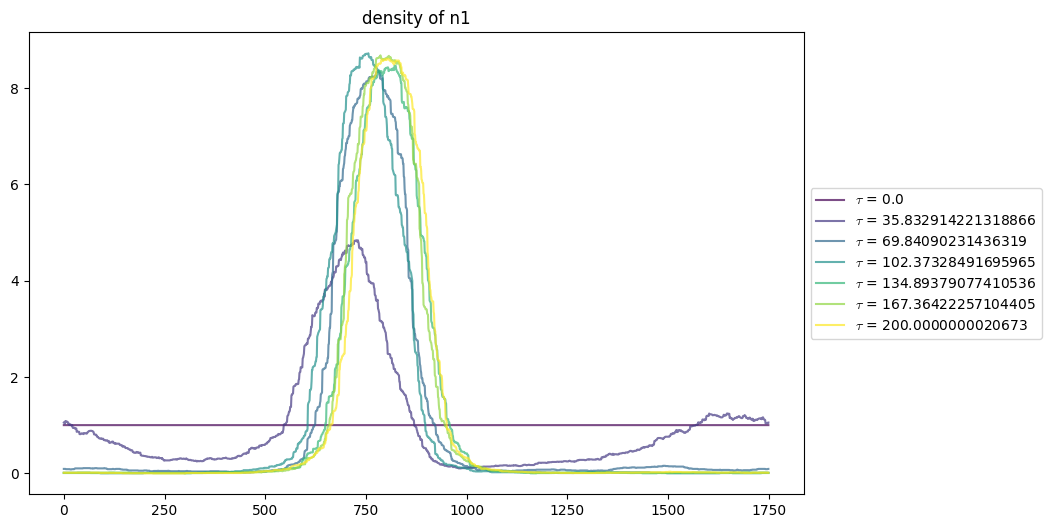

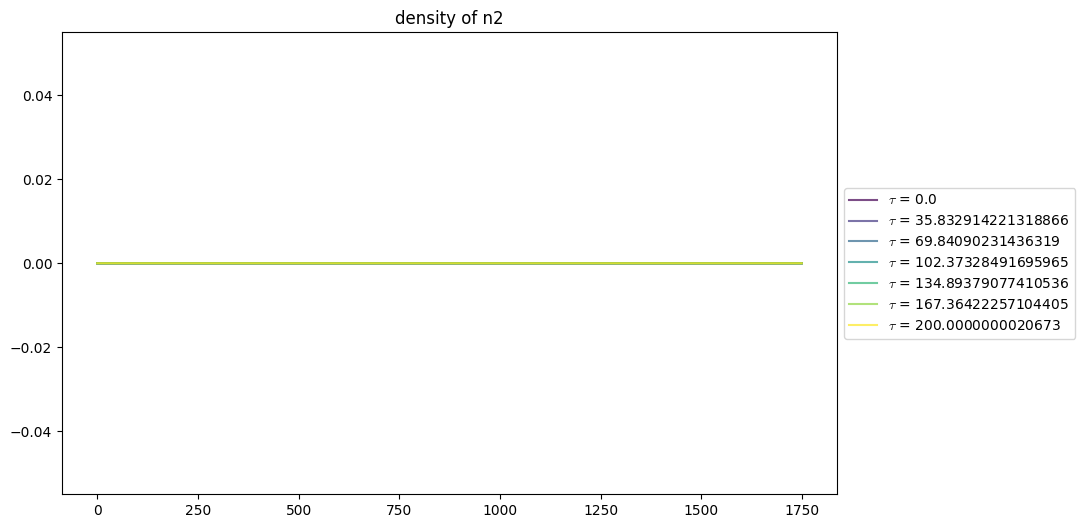

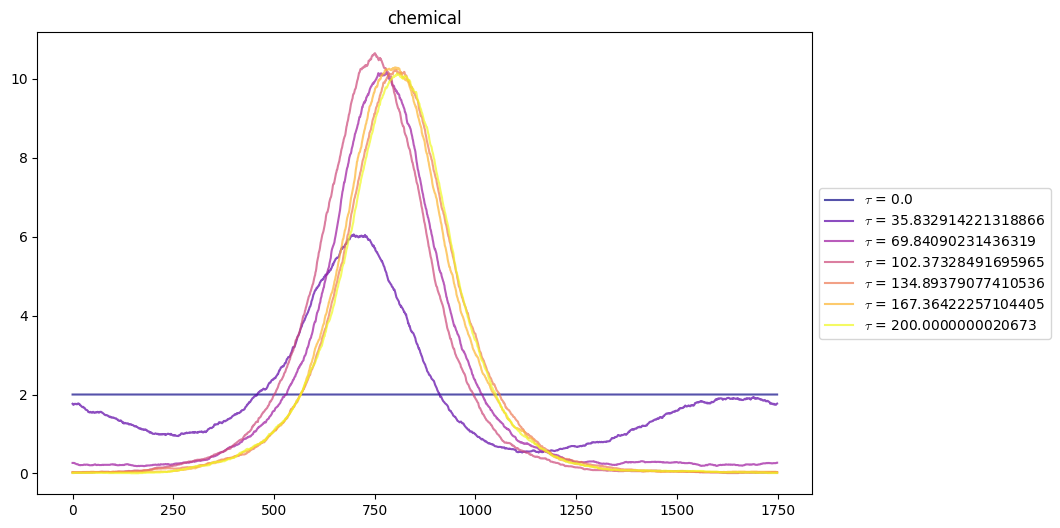

In [19]:
from helper_functions import *

path = '/scratch03.local/gtucci/micro/julia/window_t_L_12.56_Nsites_1750.00_Tfinal_200.00_2026-05-25_130048'
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2] ** delta) // 2

plot_results(occupancies_t, tau_t, w, 0, 1, 7)

In [7]:
os.listdir('/scratch03.local/gtucci/micro/julia/window_t_L_12.56_Nsites_2050.00_Tfinal_200.00_2026-05-25_130048')



['Params.bin',
 'SimState.bin',
 'chemo_rates1.npy',
 'occupancies_t.npy',
 'tau_t.npy',
 'chemo_rates2.npy',
 'cache.npy']

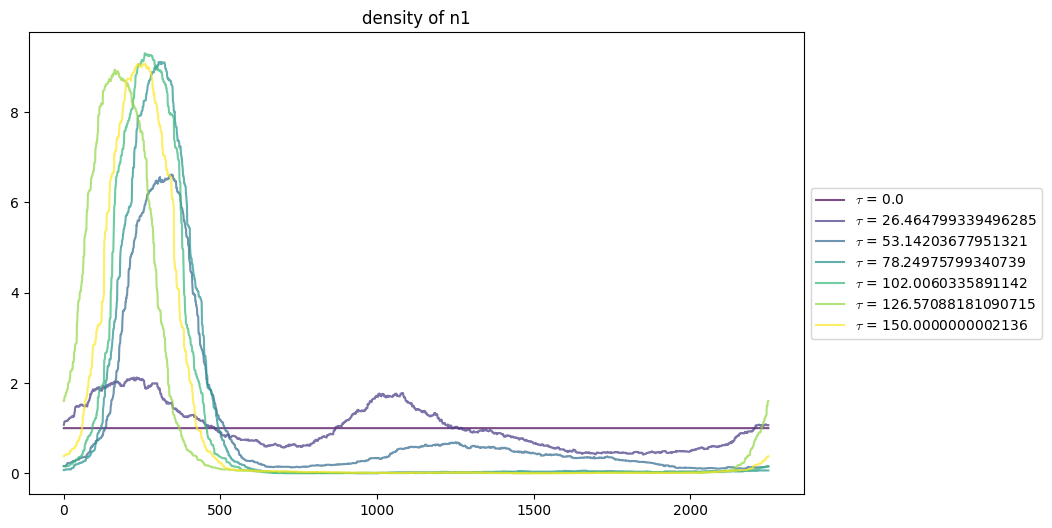

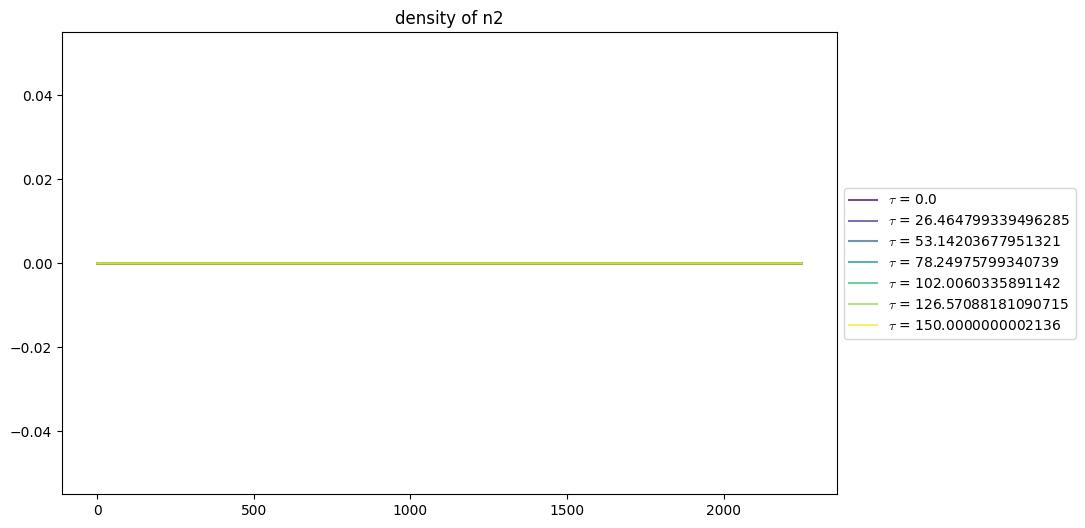

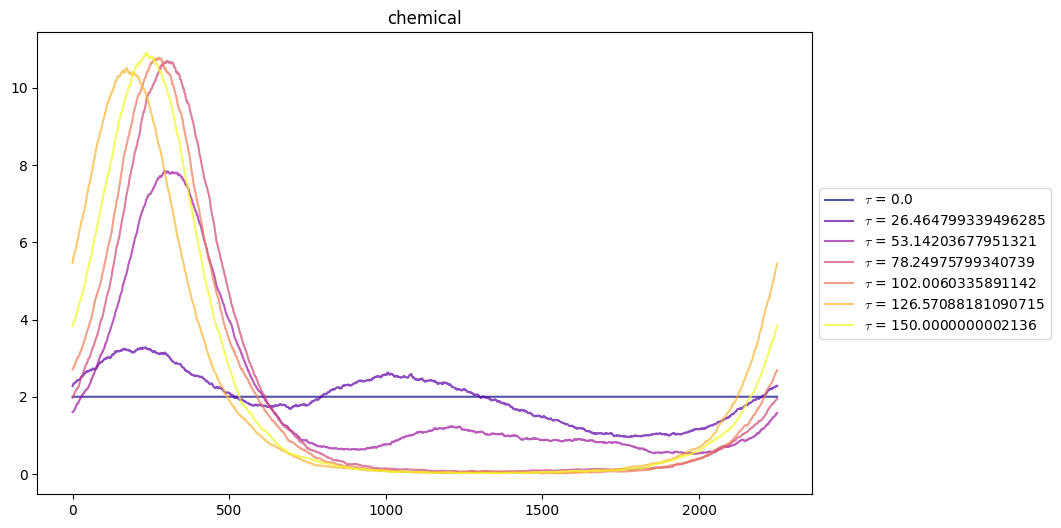

In [18]:
from helper_functions import *

path = '/scratch03.local/gtucci/micro/julia/window_t_L_12.56_Nsites_2250.00_Tfinal_150.00_2026-05-19_155535'
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2] ** delta) // 2

plot_results(occupancies_t, tau_t, w, 0, 1, 7)

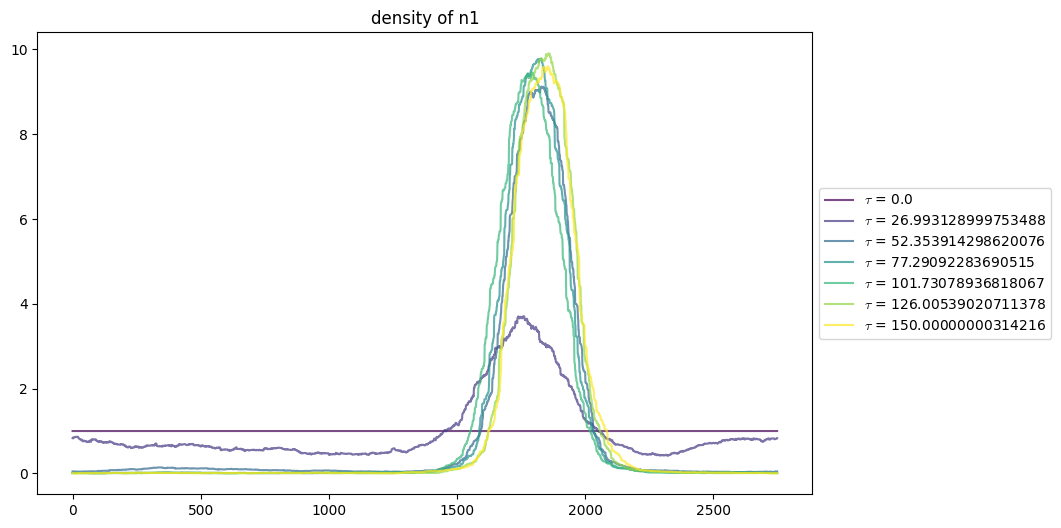

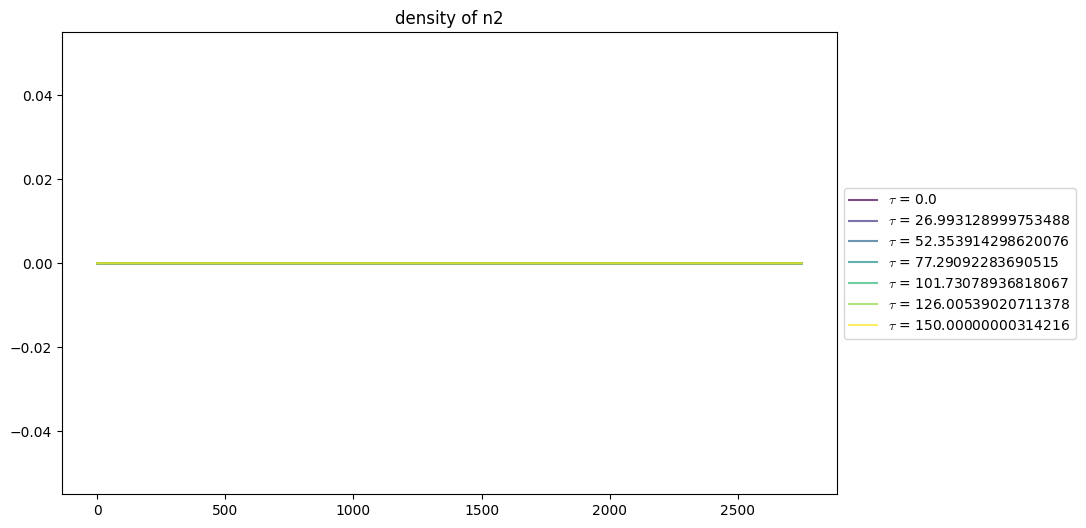

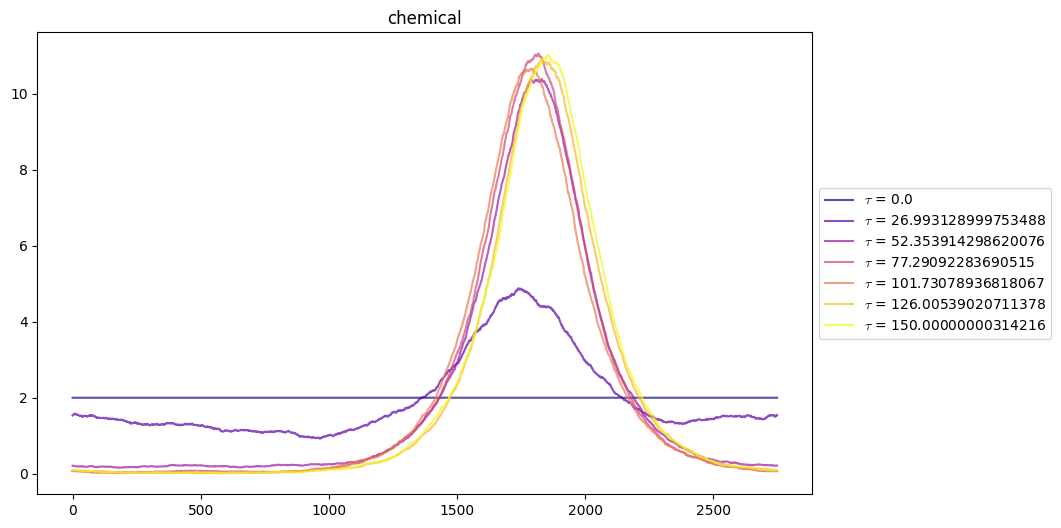

In [19]:
from helper_functions import *

path = '/scratch03.local/gtucci/micro/julia/window_t_L_12.56_Nsites_2750.00_Tfinal_150.00_2026-05-19_155535'
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2] ** delta) // 2

plot_results(occupancies_t, tau_t, w, 0, 1, 7)

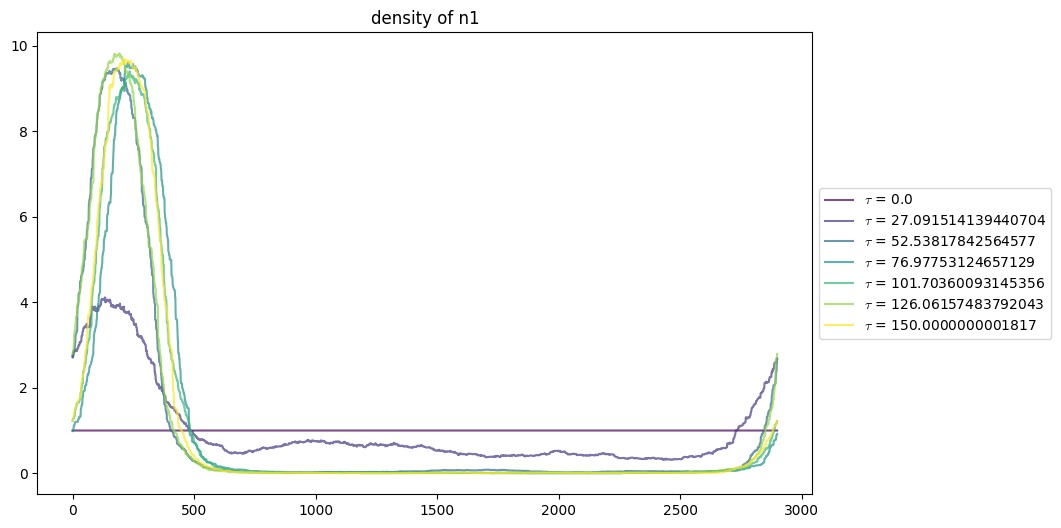

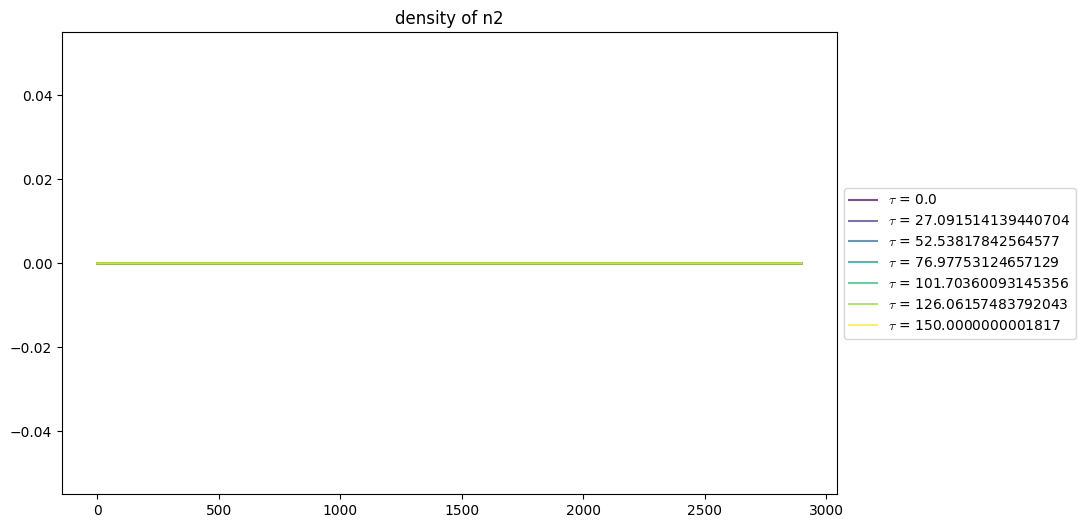

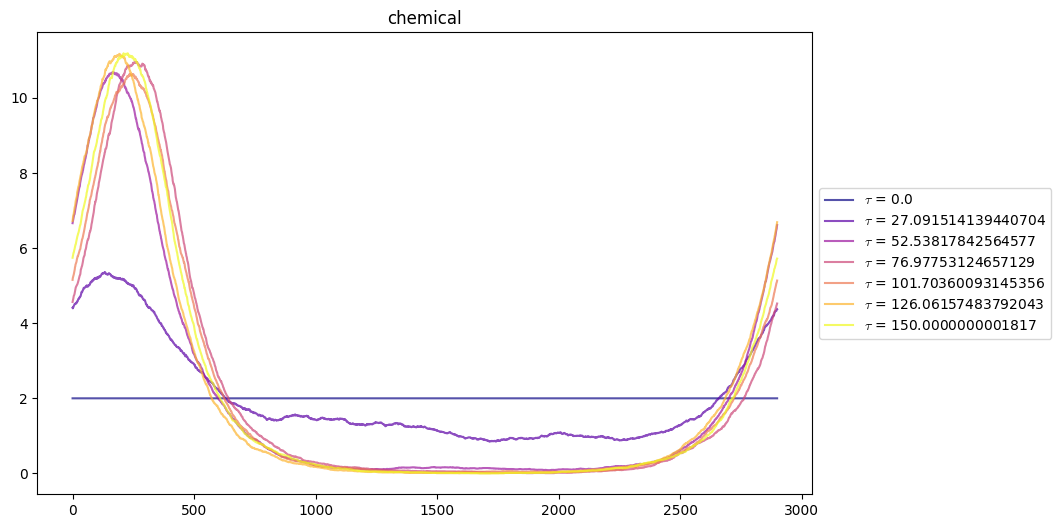

In [20]:
from helper_functions import *

path = '/scratch03.local/gtucci/micro/julia/window_t_L_12.56_Nsites_2900.00_Tfinal_150.00_2026-05-19_155535'
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2] ** delta) // 2

plot_results(occupancies_t, tau_t, w, 0, 1, 7)

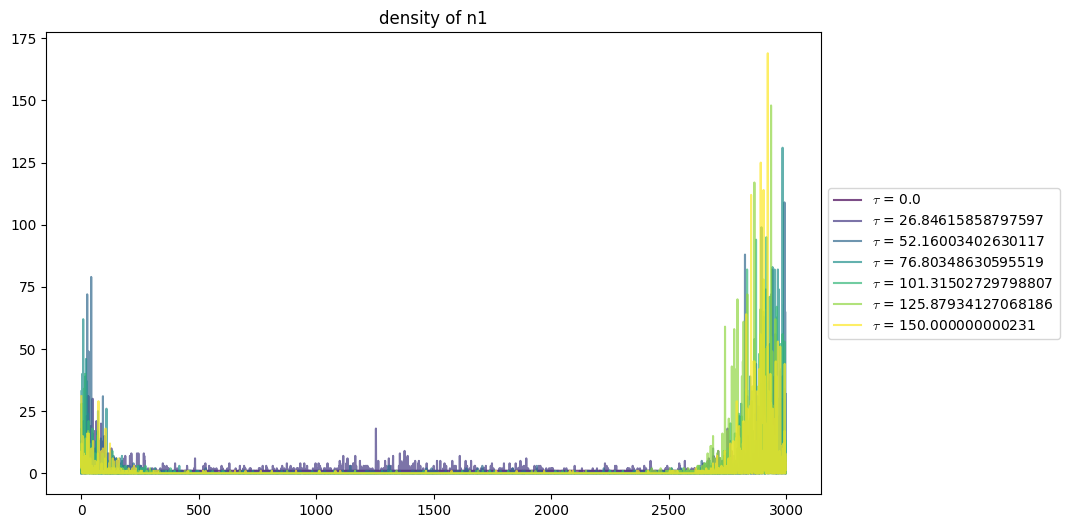

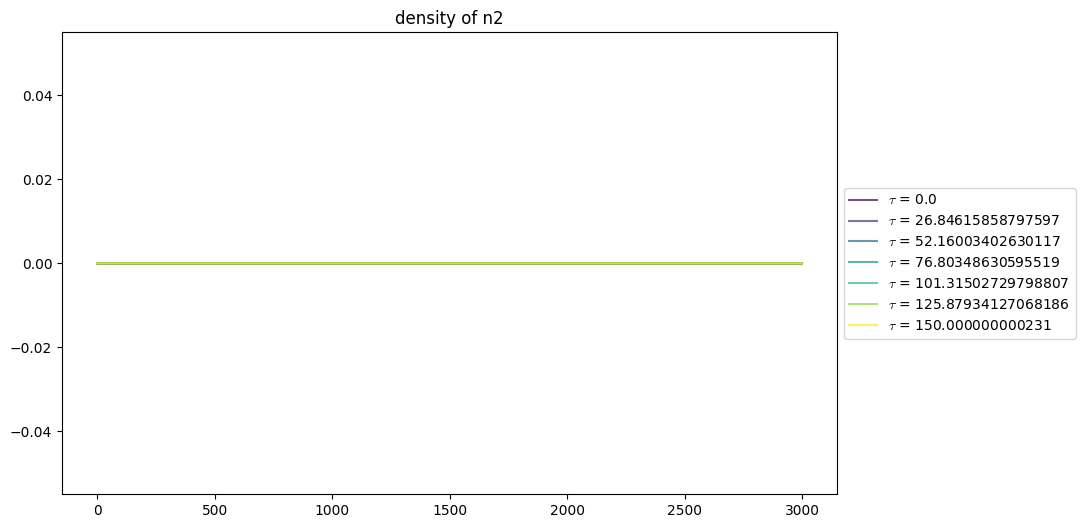

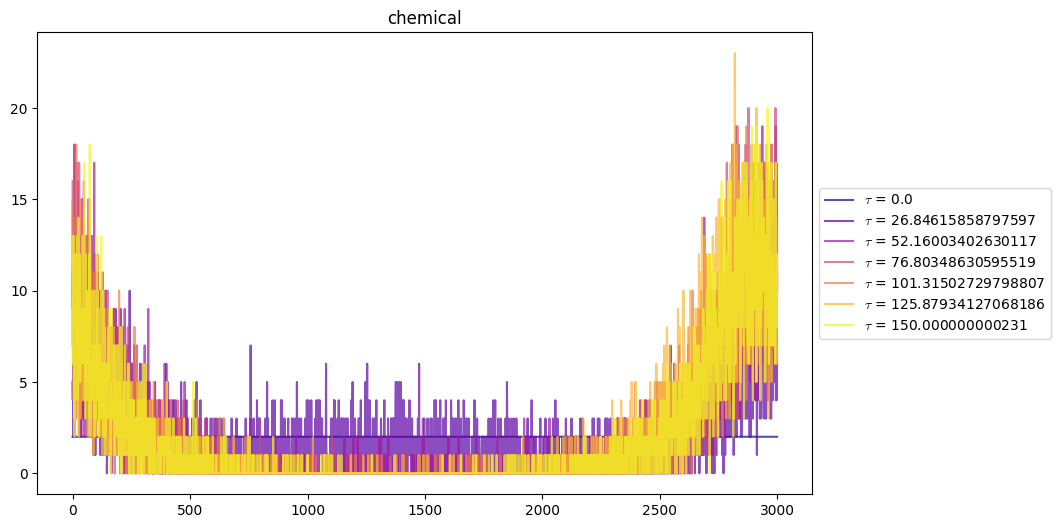

In [4]:
from helper_functions import *

delta = 0.7
path = '/scratch03.local/gtucci/micro/julia/window_t_L_12.56_Nsites_3000.00_Tfinal_150.00_2026-05-19_155535'
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2] ** delta) // 2
w = 150 // 2
w = 0
plot_results(occupancies_t, tau_t, w, 0, 1, 7)

In [35]:
os.listdir('/scratch03.local/gtucci/micro/julia/window_t_L_12.56_Nsites_3000.00_Tfinal_150.00_2026-05-19_155535')

['occupancies_t.npy',
 'chemo_rates2.npy',
 'Params.bin',
 'SimState.bin',
 'cache.npy',
 'chemo_rates1.npy',
 'tau_t.npy']

In [3]:
import matplotlib.pyplot as plt
import numpy as np

N = occupancies_t.shape[2] // 2
maxima = np.zeros(N // 20)

for i in range(maxima.shape[0]):
    maxima[i] = np.max(meso_avg(occupancies_t[-1,0,:], i * (N // maxima.shape[0])))

NameError: name 'occupancies_t' is not defined

Text(0.5, 1.0, 'Convergence of hydrodynamic limit (max peak height wrt average window size)')

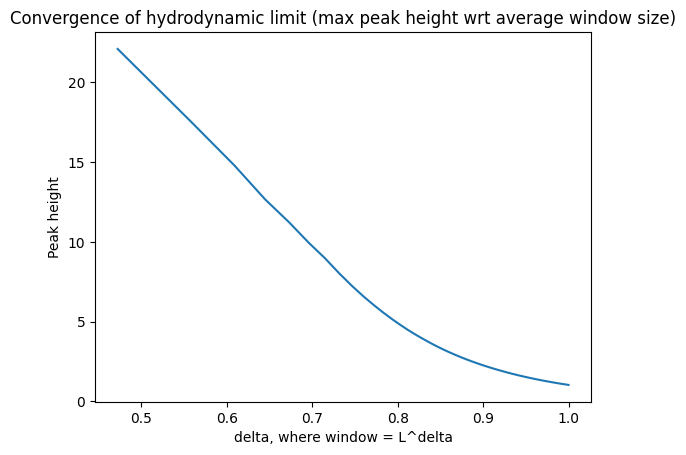

In [41]:
import matplotlib.pyplot as plt
import numpy as np

l4p = np.log(N * 2)

plt.plot((np.log(np.linspace(1, N * 2, maxima.shape[0])) / l4p) [1:], maxima[1:])
plt.xlabel('delta, where window = L^delta')
plt.ylabel('Peak height')
plt.title('Convergence of hydrodynamic limit (max peak height wrt average window size)')

w = (l)^delta

therefore delta is log(w)/log(4pi) for may 20.

In [50]:
tau_t.shape

(231,)

0.059627304571331495


1750

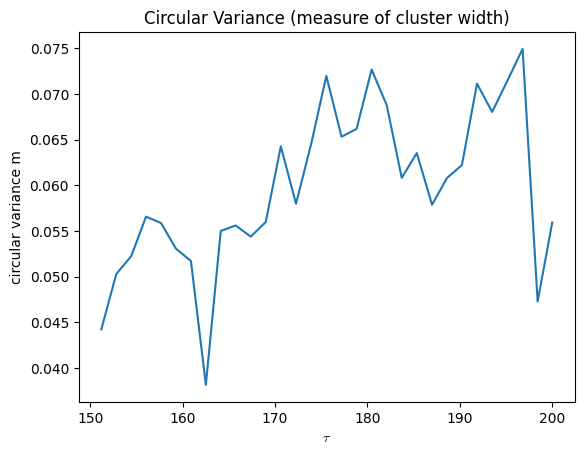

In [34]:
Nsites = occupancies_t.shape[2]

discrete_wave = np.array([np.exp((2 * np.pi / occupancies_t.shape[2]) * i * 1j) for i in range(occupancies_t.shape[2])])

product =  discrete_wave * occupancies_t[:, 0, :]
m1 = np.sum(product, axis=1) / np.sum(occupancies_t[:, 0, :], axis=1)
cv = -2 * np.log(np.abs(m1)) #circular variance

st = 90
plt.plot(tau_t[st:], cv[st:])
plt.xlabel(fr'$\tau$')
plt.ylabel('circular variance m')
print(np.mean(cv[st:]))
plt.title('Circular Variance (measure of cluster width)')
Nsites

For Dc = 1 it is like 0.55 and for Dc = 10 it is like 0.6?

In [ ]:
for f in files:  
    path = os.path_join('/scratch03.local/gtucci/micro/julia/', f)
    occupancies_t, tau_t, _, _, _ = load_sim(path)
    
    Nsites = occupancies_t.shape[2]
    
    discrete_wave = np.array([np.exp((2 * np.pi / occupancies_t.shape[2]) * i * 1j) for i in range(occupancies_t.shape[2])])
    
    product =  discrete_wave * occupancies_t[:, 0, :]
    m1 = np.sum(product, axis=1) / np.sum(occupancies_t[:, 0, :], axis=1)
    cv = -2 * np.log(np.abs(m1)) #circular variance
    
    plt.plot(tau_t[100:], circle_variances[100:])
    plt.xlabel(fr'$\tau$')
    plt.ylabel('circular variance m')
    plt.title('Circular Variance (measure of cluster width)')
    Nsites

In [5]:
print(match)

<re.Match object; span=(17, 31), match='Nsites_2250.00'>


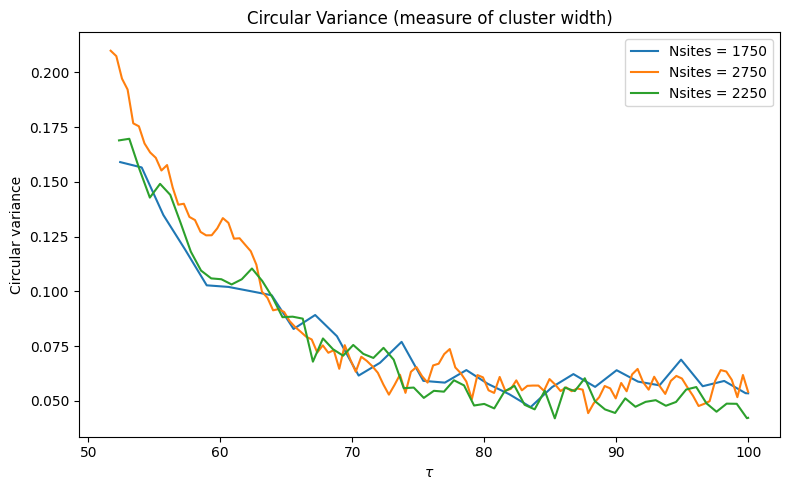

In [18]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for f in files:

    Tmatch = re.search(r'Tfinal_(\d+\.?\d*)', f)
    if not Tmatch:
        continue
    Tfinal = float(Tmatch.group(1))

    if Tfinal != 100.0:
        continue
        
    path = os.path.join('/scratch03.local/gtucci/micro/julia/', f)

    occupancies_t, tau_t, _, _, _ = load_sim(path)

    # extract Nsites from filename
    match = re.search(r'Nsites_(\d+\.?\d*)', f)

    if match:
        Nsites = int(float(match.group(1)))
    else:
        Nsites = occupancies_t.shape[2]

    # periodic phases
    N = occupancies_t.shape[2]
    theta = 2 * np.pi * np.arange(N) / N
    discrete_wave = np.exp(1j * theta)

    # compute first circular moment
    product = occupancies_t[:, 0, :] * discrete_wave

    norm = np.sum(occupancies_t[:, 0, :], axis=1)

    m1 = np.sum(product, axis=1) / norm

    start = 0.5
    # circular variance
    cv = -2 * np.log(np.abs(m1))
    plt.plot(
        tau_t[int(start * len(tau_t)):],
        cv[int(start * len(tau_t)):],
        label=f'Nsites = {Nsites}'
    )

plt.xlabel(r'$\tau$')
plt.ylabel('Circular variance')
plt.title('Circular Variance (measure of cluster width)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def periodic_derivative(array):
    N = len(array)
    dx = 1 / N
    output = np.zeros(N, dtype=float)

    for i in range(N):
        output[i] = (array[(i+1) % N] - array[(i-1) % N]) / (2 * dx)

    return output

def periodic_second_derivative_4th(array):
    dx = 1 / len(array)
    return (
        -np.roll(array, 2)
        + 16*np.roll(array, 1)
        - 30*array
        + 16*np.roll(array, -1)
        - np.roll(array, -2)
    ) / (12 * dx**2)

def spectral_filter(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(rho_hat_filtered))

def spectral_derivative_filtered(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(1j*(2*np.pi*k) * rho_hat_filtered))

def spectral_second_derivative_filtered(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(-(2*np.pi*k)**2 * rho_hat_filtered))
# plt.plot(periodic_derivative(meso_avg(occupancies_t[0, 2, :], w)))

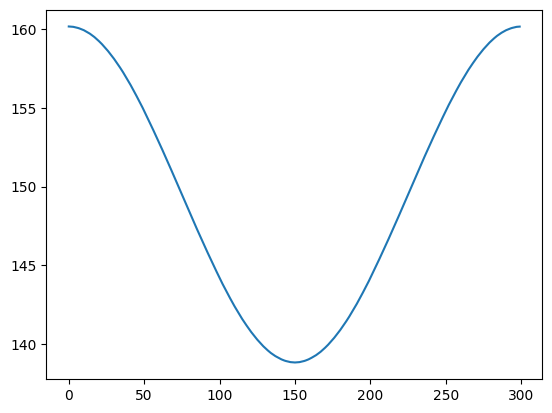

In [ ]:
plt.plot(meso_avg(occupancies_t[i, 0, :], w))

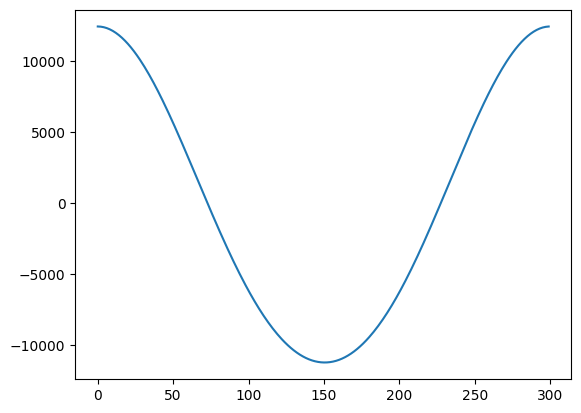

In [ ]:
lambd = 3
D = 1

i = 0
w = 15
rho = meso_avg(occupancies_t[i, 0, :], w)
gamma = meso_avg(occupancies_t[i, 2, :], w)

c = 2 / 300
rho_f = spectral_filter(rho, cutoff=c)
gamma_f = spectral_filter(gamma, cutoff=c)
rhox = spectral_derivative_filtered(rho, cutoff=c)
gammax=spectral_derivative_filtered(gamma, cutoff=c)
rhoxx = spectral_second_derivative_filtered(rho, cutoff=c)
gammaxx = spectral_second_derivative_filtered(gamma, cutoff=c)

partialt_rho_dt = 0.05 * (D + 0.5 * lambd) * rhoxx - lambd / np.sqrt(np.pi) * (rho_f * gammaxx / np.sqrt(gamma_f) + rhox * gammax / np.sqrt(gamma_f) - 0.5 * rho_f * gammax ** 2 / np.sqrt(gamma_f ** 3))
#partialt_rho -= lambd * periodic_derivative(rho * periodic_derivative(gamma) * T1(gamma)/ gamma)
plt.plot(partialt_rho)

In [ ]:
periodic_second_derivative_4th(rho)

array([-2.13162821e-10,  2.41935484e+02, -3.38709677e+03,  2.41935484e+02,
        6.39488462e-10,  8.52651283e-10,  1.06581410e-09,  1.27897692e-09,
        2.41935484e+02, -3.38709677e+03,  2.41935484e+02, -3.83693077e-09,
       -3.19744231e-09, -2.77111667e-09,  4.83870968e+02, -7.01612903e+03,
        3.87096774e+03, -2.41935484e+02, -2.77111667e-09,  2.41935484e+02,
       -3.38709677e+03,  2.41935484e+02, -2.55795385e-09, -5.11590770e-09,
        2.41935484e+02, -3.38709677e+03,  2.41935484e+02, -8.52651283e-10,
        2.41935484e+02, -3.38709677e+03,  2.41935484e+02, -2.34479103e-09,
       -1.06581410e-09,  3.83693077e-09, -5.11590770e-09,  2.41935484e+02,
       -3.38709677e+03,  2.41935484e+02,  1.06581410e-09, -4.26325641e-09,
        4.05009359e-09, -1.27897692e-09,  2.41935484e+02, -3.38709677e+03,
        2.41935484e+02, -2.41935484e+02,  3.62903226e+03, -3.62903226e+03,
        2.41935484e+02,  2.41935484e+02, -3.62903226e+03,  3.62903226e+03,
        4.68958206e-09, -

In [ ]:
np.mean(occupancies_t[-1, 2,:]), np.var(occupancies_t[-1, 2,:])

(np.float64(223.21666666666667), np.float64(269.6097222222222))

In [ ]:
np.mean(occupancies_t[-1, 0,:]), np.var(occupancies_t[-1, 0,:])

(np.float64(149.50666666666666), np.float64(176.80328888888891))

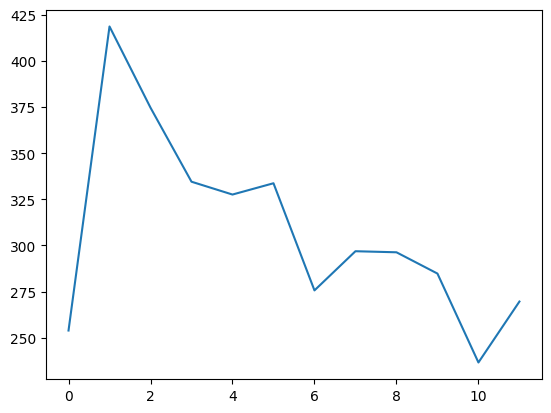

In [ ]:
plt.plot([np.var(occupancies_t[i, 2,:]) for i in range(occupancies_t.shape[0])])

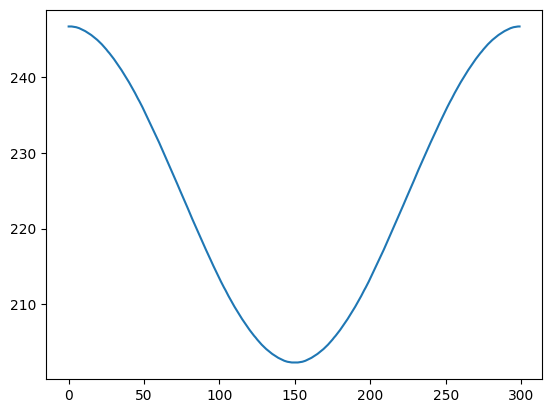

In [ ]:
meso = np.zeros(occupancies_t.shape, dtype=float)

for i, _ in enumerate(occupancies_t):
    meso[i,2,:] = meso_avg(occupancies_t[i,2,:], w)

plt.plot(meso[0, 2,:])

In [ ]:
meso.shape

(12, 3, 300)

In [ ]:
import numpy as np

# choose 10 indices (example: random)
indices = np.random.choice(len(tau_t), size=49, replace=False)

c = np.mean(meso[0, 2, :])
a = meso[0, 2, 0] - c
print(c)

# get elements at those indices
meso = meso[indices]
tau_t = tau_t[indices]

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exponential(a, c):
    def f(x, b):
        return a * np.exp(b * x) + c
    return f

p_opt, p_cov = curve_fit(exponential(a, c), tau_t, meso[:,2, 0], p0=(-20))

x_fit = np.linspace(min(tau_t), max(tau_t), 100)
y_fit = exponential(a, c)(x_fit, *p_opt)

plt.figure(figsize=(8, 5))

plt.scatter(tau_t[:], meso[:,2, 0], color='gray', alpha=0.4, label='Data (Col 20)')

plt.plot(x_fit, y_fit, color='red', linewidth=2, 
         label=fr'Fit: $ae^{{b\tau}} + c$ with $(a, b, c)$ = {p_opt}')

# 3. Formatting
plt.xlabel(r'$\tau$')
plt.ylabel('Occupancy')
plt.title('Exponential Fit to Occupancy Data')

# Snap the frame to the data
plt.axis('tight') 

# Display the legend
plt.legend()

plt.show()

24. sth for kappa = 1
24.8 for kappa = 2
and 
33 or so for kappa = 10 (should be like 30) and 600 entries
let's see what it is for 400

In [ ]:
(5 / 3)**3

In [ ]:
# we should be getting a decay rate of Dc / 2 * (2pi / N)^2 - kappa, where Dc and kappa are the numbers in the simulation for 200 sites it's 1 * 200 * 2

0.1*(2 * np.pi) ** 2 + 1